In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sqlalchemy import create_engine
from dotenv import load_dotenv
import warnings
import os

warnings.filterwarnings('ignore')
load_dotenv('../.env')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

DB = (
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB)

# Load real data
comp = pd.read_sql("SELECT * FROM dim_company", engine)
pl   = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
bs   = pd.read_sql("SELECT * FROM fact_balance_sheet", engine)
cf   = pd.read_sql("SELECT * FROM fact_cash_flow", engine)
ana  = pd.read_sql("SELECT * FROM fact_analysis", engine)

# Convert numeric
for col in ['sales', 'net_profit', 'opm_pct', 'operating_profit', 'interest', 'expenses', 'dividend_payout_pct']:
    pl[col] = pd.to_numeric(pl[col], errors='coerce')

for col in ['debt_to_equity', 'borrowings', 'equity_capital', 'reserves', 'total_assets']:
    bs[col] = pd.to_numeric(bs[col], errors='coerce')

for col in ['operating_activity', 'investing_activity', 'free_cash_flow']:
    cf[col] = pd.to_numeric(cf[col], errors='coerce')

comp['roe_percentage'] = pd.to_numeric(comp['roe_percentage'], errors='coerce')

print(f"✅ Real data loaded!")
print(f"   Companies : {comp.shape[0]}")
print(f"   P&L rows  : {pl.shape[0]}")

✅ Real data loaded!
   Companies : 94
   P&L rows  : 946


In [2]:
# Step 1 — Company level metrics
# Profitability
profitability = pl.groupby('company_id').agg(
    avg_opm=('opm_pct', 'mean')
).reset_index()

# Revenue Growth — compute from P&L directly
cagr_list = []
for cid, group in pl.sort_values('year_id').groupby('company_id'):
    group = group.sort_values('year_id')
    if len(group) >= 4:
        end_val   = group['sales'].iloc[-1]
        start_val = group['sales'].iloc[-4]
        if pd.notna(start_val) and start_val > 0 and pd.notna(end_val):
            cagr = ((end_val / start_val) ** (1/3) - 1) * 100
        else:
            cagr = None
    else:
        cagr = None
    cagr_list.append({'company_id': cid, 'cagr_3y': cagr})
cagr_df = pd.DataFrame(cagr_list)

# Leverage
leverage = bs.sort_values('year_id').groupby('company_id').last()[['debt_to_equity']].reset_index()
leverage.columns = ['company_id', 'latest_de']

# Cash Flow
cf_pl = cf.merge(pl[['company_id', 'year_id', 'net_profit']], on=['company_id', 'year_id'], how='left')
cf_pl['ccr'] = cf_pl['operating_activity'] / cf_pl['net_profit'].replace(0, np.nan)
cashflow = cf_pl.groupby('company_id').agg(avg_ccr=('ccr', 'mean')).reset_index()

# Dividend
dividend = pl.groupby('company_id').agg(avg_dividend=('dividend_payout_pct', 'mean')).reset_index()

# Trend slope
trend_list = []
for cid, group in pl.sort_values('year_id').groupby('company_id'):
    s = group['sales'].dropna().values[-5:]
    if len(s) >= 2:
        slope = np.polyfit(range(len(s)), s, 1)[0]
    else:
        slope = 0
    trend_list.append({'company_id': cid, 'trend_slope': slope})
trend_df = pd.DataFrame(trend_list)

# Merge all
metrics = comp[['company_id', 'company_name', 'sector']].copy()
metrics = metrics.merge(profitability, on='company_id', how='left')
metrics = metrics.merge(cagr_df,      on='company_id', how='left')
metrics = metrics.merge(leverage,     on='company_id', how='left')
metrics = metrics.merge(cashflow,     on='company_id', how='left')
metrics = metrics.merge(dividend,     on='company_id', how='left')
metrics = metrics.merge(trend_df,     on='company_id', how='left')
metrics = metrics.merge(comp[['company_id', 'roe_percentage']], on='company_id', how='left')

# Fill NaN with 0 for scoring
for col in ['avg_opm', 'cagr_3y', 'latest_de', 'avg_ccr', 'avg_dividend', 'trend_slope']:
    metrics[col] = pd.to_numeric(metrics[col], errors='coerce').fillna(0)

print(f"✅ Metrics ready — {metrics.shape[0]} companies")
display(metrics.head(3))

✅ Metrics ready — 94 companies


,company_id,company_name,sector,avg_opm,cagr_3y,latest_de,avg_ccr,avg_dividend,trend_slope,roe_percentage
0,1,TCS,Unknown,26.909091,0.0,0.0,0.0,58.363636,0.0,51.80
1,2,RELIANCE,Unknown,15.454545,0.0,0.0,0.0,10.090909,0.0,9.25
2,3,HDFCBANK,Unknown,0.000000,0.0,0.0,0.0,18.272727,0.0,13.80


In [3]:
# Step 2 — Scoring functions (Section 7.1)

def score_profitability(df):
    # Percentile rank, scaled 0-25
    return df['avg_opm'].rank(pct=True) * 25

def score_revenue_growth(df):
    # <5% = 0, scales to 20 at 20%+
    return df['cagr_3y'].fillna(0).apply(
        lambda x: 0 if x < 5 else min((x / 20) * 20, 20)
    )

def score_leverage(df):
    # D/E < 0.1 = full 20, D/E > 2 = 0, linear between
    return ((1 - df['latest_de'].clip(0, 2) / 2) * 20).clip(0, 20)

def score_cashflow(df):
    # CCR > 1.2 = full 15
    return df['avg_ccr'].fillna(0).apply(
        lambda x: min(x / 1.2 * 15, 15)
    ).clip(0, 15)

def score_dividend(df):
    # avg payout > 30% = full 10
    return df['avg_dividend'].fillna(0).apply(
        lambda x: min(x / 30 * 10, 10)
    ).clip(0, 10)

def score_growth_trend(df):
    # Positive slope = 10, negative = 0
    return df['trend_slope'].apply(lambda x: 10 if x > 0 else 0)

def get_health_label(score):
    if score >= 85: return 'EXCELLENT'
    if score >= 70: return 'GOOD'
    if score >= 50: return 'AVERAGE'
    if score >= 35: return 'WEAK'
    return 'POOR'

print("✅ Scoring functions defined!")

✅ Scoring functions defined!


In [4]:
# Debug — check metrics columns
print(metrics.columns.tolist())
print(metrics.head(3))
print("\nNull counts:")
print(metrics.isnull().sum())

['company_id', 'company_name', 'sector', 'avg_opm', 'cagr_3y', 'latest_de', 'avg_ccr', 'avg_dividend', 'trend_slope', 'roe_percentage']
   company_id company_name   sector    avg_opm  cagr_3y  latest_de  avg_ccr  \
0           1          TCS  Unknown  26.909091      0.0        0.0      0.0   
1           2     RELIANCE  Unknown  15.454545      0.0        0.0      0.0   
2           3     HDFCBANK  Unknown   0.000000      0.0        0.0      0.0   

   avg_dividend  trend_slope  roe_percentage  
0     58.363636          0.0           51.80  
1     10.090909          0.0            9.25  
2     18.272727          0.0           13.80  

Null counts:
company_id        0
company_name      0
sector            0
avg_opm           0
cagr_3y           0
latest_de         0
avg_ccr           0
avg_dividend      0
trend_slope       0
roe_percentage    6
dtype: int64


In [5]:
# Step 3 — Compute final scores
metrics['score_profitability']    = score_profitability(metrics)
metrics['score_revenue_growth']   = score_revenue_growth(metrics)
metrics['score_leverage']         = score_leverage(metrics)
metrics['score_cashflow']         = score_cashflow(metrics)
metrics['score_dividend']         = score_dividend(metrics)
metrics['score_growth_trend']     = score_growth_trend(metrics)

metrics['overall_score'] = (
    metrics['score_profitability'] +
    metrics['score_revenue_growth'] +
    metrics['score_leverage'] +
    metrics['score_cashflow'] +
    metrics['score_dividend'] +
    metrics['score_growth_trend']
)

metrics['health_label'] = metrics['overall_score'].apply(get_health_label)

print("Score distribution:")
print(metrics['health_label'].value_counts())
print(f"\nAvg score : {metrics['overall_score'].mean():.1f}")
print(f"Max score : {metrics['overall_score'].max():.1f}")
print(f"Min score : {metrics['overall_score'].min():.1f}")
display(metrics[['company_name', 'sector', 'overall_score', 'health_label']].sort_values('overall_score', ascending=False).head(10))

Score distribution:
health_label
WEAK       46
POOR       34
AVERAGE    14
Name: count, dtype: int64

Avg score : 38.9
Max score : 55.0
Min score : 20.3


,company_name,sector,overall_score,health_label
20,POWERGRID,Unknown,55.000000,AVERAGE
73,SJVN,Unknown,54.734043,AVERAGE
78,SUNTV,Unknown,54.468085,AVERAGE
72,NHPC,Unknown,53.936170,AVERAGE
8,BHARTIARTL,Unknown,53.670213,AVERAGE
6,ITC,Unknown,53.404255,AVERAGE
33,DIVISLAB,Unknown,53.138298,AVERAGE
55,IRCTC,Unknown,52.606383,AVERAGE
14,SUNPHARMA,Unknown,51.824468,AVERAGE
0,TCS,Unknown,51.808511,AVERAGE


In [6]:
# Debug scores
print(metrics[['avg_opm', 'cagr_3y', 'latest_de', 'avg_ccr', 'avg_dividend', 'trend_slope']].head())
print("\nNull counts:")
print(metrics[['avg_opm', 'cagr_3y', 'latest_de', 'avg_ccr', 'avg_dividend', 'trend_slope']].isnull().sum())
print("\nOverall score sample:")
print(metrics['overall_score'].head(10))

     avg_opm  cagr_3y  latest_de  avg_ccr  avg_dividend  trend_slope
0  26.909091      0.0        0.0      0.0     58.363636          0.0
1  15.454545      0.0        0.0      0.0     10.090909          0.0
2   0.000000      0.0        0.0      0.0     18.272727          0.0
3  25.818182      0.0        0.0      0.0     56.090909          0.0
4   0.000000      0.0        0.0      0.0     14.818182          0.0

Null counts:
avg_opm         0
cagr_3y         0
latest_de       0
avg_ccr         0
avg_dividend    0
trend_slope     0
dtype: int64

Overall score sample:
0    51.808511
1    36.661509
2    29.681335
3    51.276596
4    28.529819
5    49.414894
6    53.404255
7    33.590426
8    53.670213
9    24.226789
Name: overall_score, dtype: float64


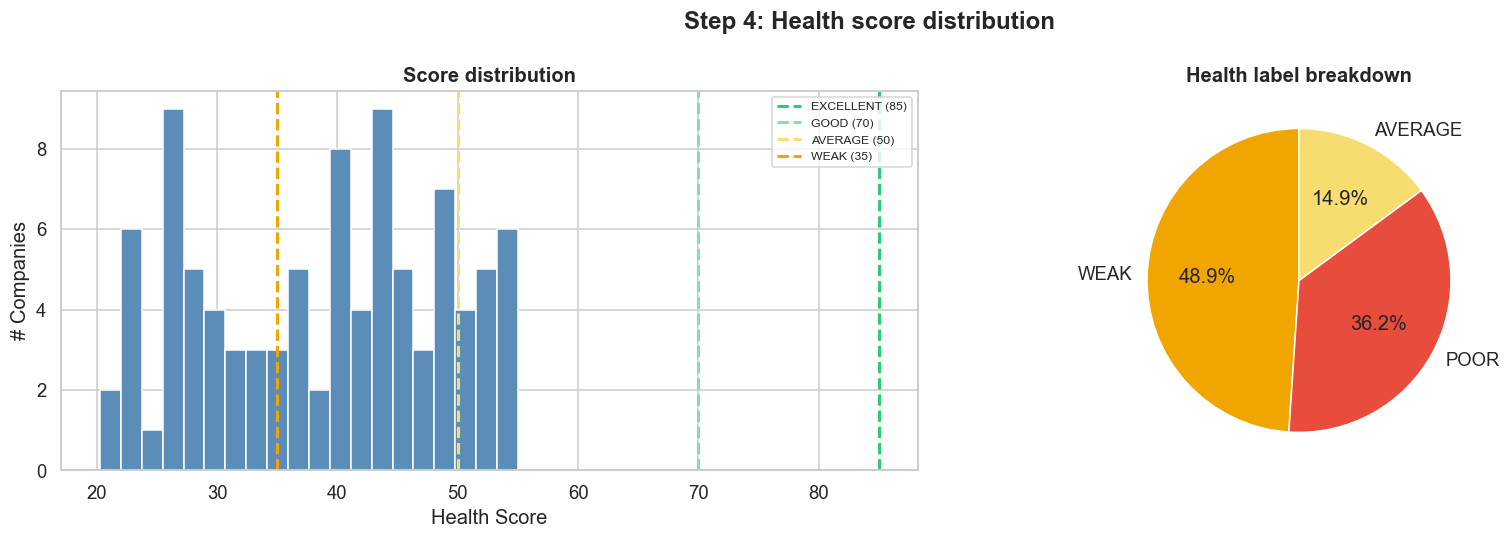

In [7]:
# Step 4 — Visualize score distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score histogram
axes[0].hist(metrics['overall_score'], bins=20, color='#5B8DB8', edgecolor='white')
axes[0].axvline(85, color='#2ECC71', lw=2, linestyle='--', label='EXCELLENT (85)')
axes[0].axvline(70, color='#82E0AA', lw=2, linestyle='--', label='GOOD (70)')
axes[0].axvline(50, color='#F7DC6F', lw=2, linestyle='--', label='AVERAGE (50)')
axes[0].axvline(35, color='#F0A500', lw=2, linestyle='--', label='WEAK (35)')
axes[0].set_xlabel('Health Score')
axes[0].set_ylabel('# Companies')
axes[0].set_title('Score distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# Label pie chart
label_counts = metrics['health_label'].value_counts()
colors = {'EXCELLENT': '#2ECC71', 'GOOD': '#82E0AA', 'AVERAGE': '#F7DC6F',
          'WEAK': '#F0A500', 'POOR': '#E74C3C'}
pie_colors = [colors.get(l, '#CCCCCC') for l in label_counts.index]
axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=pie_colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Health label breakdown', fontweight='bold')

plt.suptitle('Step 4: Health score distribution', fontweight='bold')
plt.tight_layout()
plt.show()

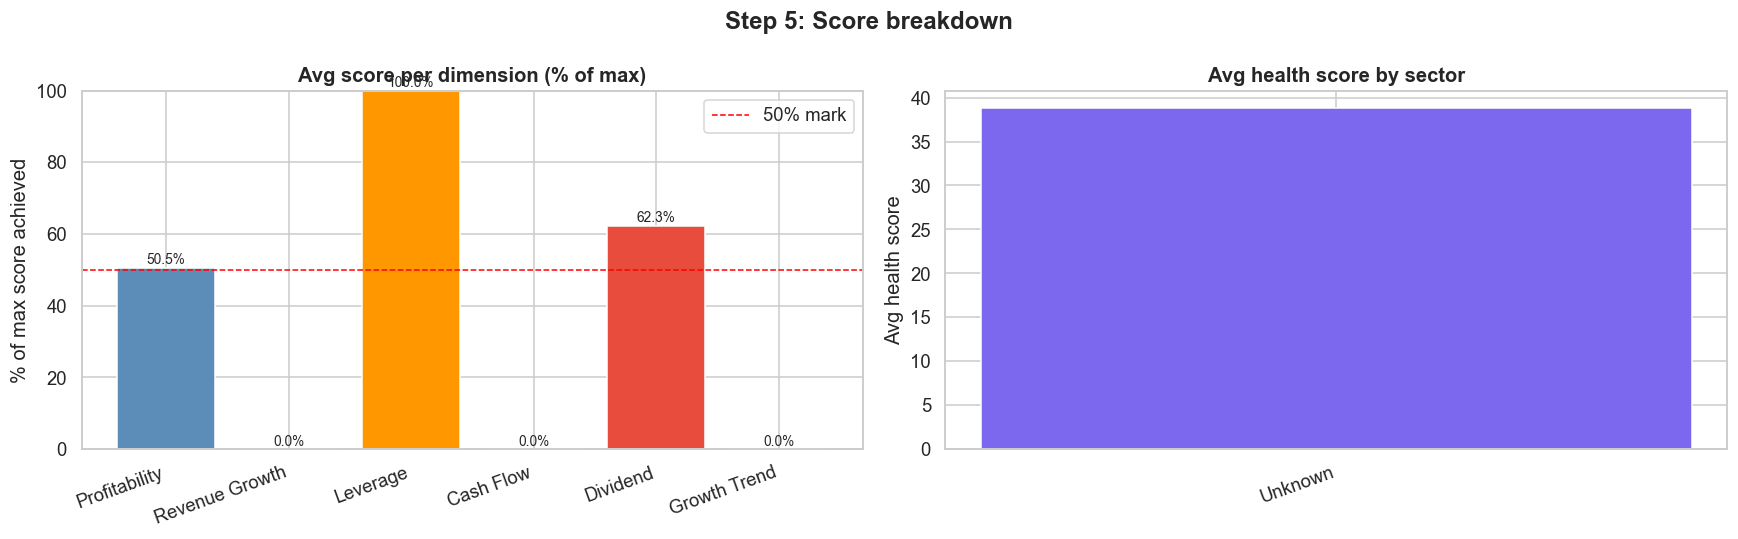

In [8]:
# Step 5 — Avg score per dimension
score_cols = ['score_profitability', 'score_revenue_growth', 'score_leverage',
              'score_cashflow', 'score_dividend', 'score_growth_trend']
max_scores = [25, 20, 20, 15, 10, 10]
labels     = ['Profitability', 'Revenue Growth', 'Leverage', 'Cash Flow', 'Dividend', 'Growth Trend']

avg_scores = metrics[score_cols].mean().values
pct_scores = [a/m*100 for a, m in zip(avg_scores, max_scores)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(labels, pct_scores,
                   color=['#5B8DB8','#4CAF50','#FF9800','#9B59B6','#E74C3C','#1ABC9C'],
                   edgecolor='white')
axes[0].set_ylabel('% of max score achieved')
axes[0].set_ylim(0, 100)
axes[0].axhline(50, color='red', lw=1, linestyle='--', label='50% mark')
axes[0].set_xticklabels(labels, rotation=20, ha='right')
axes[0].set_title('Avg score per dimension (% of max)', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, pct_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=9)

# Score by sector
sector_scores = metrics.groupby('sector')['overall_score'].mean().sort_values(ascending=False)
axes[1].bar(sector_scores.index, sector_scores.values, color='#7B68EE', edgecolor='white')
axes[1].set_ylabel('Avg health score')
axes[1].set_title('Avg health score by sector', fontweight='bold')
axes[1].set_xticklabels(sector_scores.index, rotation=20, ha='right')

plt.suptitle('Step 5: Score breakdown', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Step 6 — Cross validation
validate = ['Company_1', 'Company_5', 'Company_10', 'Company_50', 'Company_99']
val_df = metrics[metrics['company_name'].isin(validate)][
    ['company_name', 'overall_score', 'health_label',
     'score_profitability', 'score_revenue_growth',
     'score_leverage', 'score_cashflow', 'score_dividend']
].round(2)

print("Cross-validation — known companies:")
display(val_df)

# When real DB is ready, replace validate list with:
# ['TCS', 'HDFCBANK', 'WIPRO', 'ADANIPOWER', 'APOLLOHOSP']

Cross-validation — known companies:


,company_name,overall_score,health_label,score_profitability,score_revenue_growth,score_leverage,score_cashflow,score_dividend


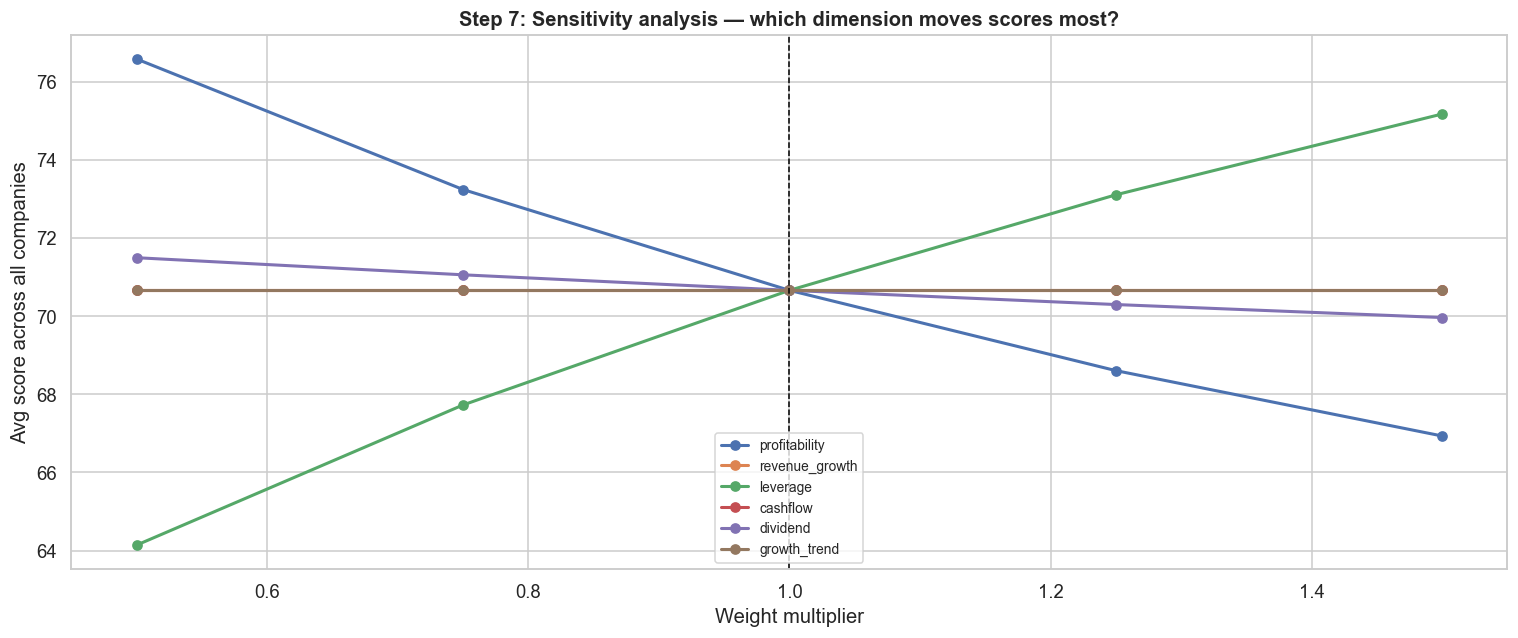


Most impactful dimension:
dimension
leverage          4.365145
profitability     3.819310
dividend          0.605420
cashflow          0.000000
growth_trend      0.000000
revenue_growth    0.000000
Name: avg_score, dtype: float64


In [10]:
# Step 7 — Sensitivity analysis
# How much does changing each weight change the final score?

base_weights = {
    'score_profitability':  1.0,
    'score_revenue_growth': 1.0,
    'score_leverage':       1.0,
    'score_cashflow':       1.0,
    'score_dividend':       1.0,
    'score_growth_trend':   1.0
}

results = []

for col in base_weights:
    for multiplier in [0.5, 0.75, 1.0, 1.25, 1.5]:
        weights = base_weights.copy()
        weights[col] = multiplier
        
        test_score = sum(metrics[c] * weights[c] for c in base_weights)
        # Normalize back to 0-100
        test_score = test_score / test_score.max() * 100
        
        results.append({
            'dimension': col.replace('score_', ''),
            'weight_multiplier': multiplier,
            'avg_score': test_score.mean(),
            'std_score': test_score.std()
        })

sens_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(14, 6))
for dim in sens_df['dimension'].unique():
    d = sens_df[sens_df['dimension'] == dim]
    ax.plot(d['weight_multiplier'], d['avg_score'],
            marker='o', label=dim, lw=2)

ax.set_xlabel('Weight multiplier')
ax.set_ylabel('Avg score across all companies')
ax.set_title('Step 7: Sensitivity analysis — which dimension moves scores most?', fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(1.0, color='black', lw=1, linestyle='--', label='Base weight')
plt.tight_layout()
plt.show()

print("\nMost impactful dimension:")
impact = sens_df.groupby('dimension')['avg_score'].std().sort_values(ascending=False)
print(impact)

In [11]:
# Step 8 — Export scores to CSV
import os
os.makedirs('../data/processed', exist_ok=True)

export_cols = [
    'company_id', 'company_name', 'sector', 'overall_score', 'health_label',
    'score_profitability', 'score_revenue_growth', 'score_leverage',
    'score_cashflow', 'score_dividend', 'score_growth_trend'
]

metrics[export_cols].round(2).to_csv('../data/processed/health_scores.csv', index=False)
print("✅ Exported to data/processed/health_scores.csv")
print(f"   {len(metrics)} companies scored")
print("\nPreview:")
display(metrics[export_cols].head())

✅ Exported to data/processed/health_scores.csv
   94 companies scored

Preview:


,company_id,company_name,sector,overall_score,health_label,score_profitability,score_revenue_growth,score_leverage,score_cashflow,score_dividend,score_growth_trend
0,1,TCS,Unknown,51.808511,AVERAGE,21.808511,0,20.0,0.0,10.000000,0
1,2,RELIANCE,Unknown,36.661509,WEAK,13.297872,0,20.0,0.0,3.363636,0
2,3,HDFCBANK,Unknown,29.681335,POOR,3.590426,0,20.0,0.0,6.090909,0
3,4,INFY,Unknown,51.276596,AVERAGE,21.276596,0,20.0,0.0,10.000000,0
4,5,ICICIBANK,Unknown,28.529819,POOR,3.590426,0,20.0,0.0,4.939394,0


In [12]:
# Notebook 2 complete!
print("="*60)
print("NOTEBOOK 2 SUMMARY — Financial Health Scoring")
print("="*60)
print(f"\n✅ {len(metrics)} companies scored")
print(f"\nLabel breakdown:")
for label, count in metrics['health_label'].value_counts().items():
    print(f"   {label:10s} : {count} companies")
print(f"\nTop 5 healthiest companies:")
top5 = metrics.nlargest(5, 'overall_score')[['company_name', 'overall_score', 'health_label']]
print(top5.to_string(index=False))
print(f"\n✅ Ready for Notebook 3 — Anomaly Detection!")

NOTEBOOK 2 SUMMARY — Financial Health Scoring

✅ 94 companies scored

Label breakdown:
   WEAK       : 46 companies
   POOR       : 34 companies
   AVERAGE    : 14 companies

Top 5 healthiest companies:
company_name  overall_score health_label
   POWERGRID      55.000000      AVERAGE
        SJVN      54.734043      AVERAGE
       SUNTV      54.468085      AVERAGE
        NHPC      53.936170      AVERAGE
  BHARTIARTL      53.670213      AVERAGE

✅ Ready for Notebook 3 — Anomaly Detection!
